# IPO Market Gains

### Table of Contents

### Intro

When a company decides to go public, it embarks on a complex financial journey that transforms its ownership and market valuation. Through an initial public offering (IPO), the company works with investment banks to set an initial stock price that reflects its perceived value. However, the true test comes on the first day of public trading, when investors' collective judgment determines the stock's actual worth. This moment can result in a listing gain, where the stock price rises above the initial offering price, signify a neutral market response, or even experience a price decline, depending on investor confidence, market conditions, and the company's perceived potential.

In this project, we will build a deep learning model that predicts weather or not a business in the Indian Market will have positive listing gains. Our goal is to exemplify some of the very useful things pytorch and deep learning models can do for us and to demonstrate the different tools we can use to help our model be more accurate. We will be using a dataset is based off of [moneycontrol](https://www.moneycontrol.com/ipo/listed-ipos/?classic=true). It consists details from former IPOs in the Indian market. 

### Set Up

First things first, in the code below, we will import our libraries and bring in our data.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import copy

In [2]:
df = pd.read_csv('Indian_IPO_Market_Data.csv')

### Intial Exploration

With our libraries and data now ready, we will do some exploring and make our first observations of the data in the code below.

In [3]:
df

,Date,IPOName,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
0,03/02/10,Infinite Comp,189.80,48.44,106.02,11.08,43.22,165,11.82
1,08/02/10,Jubilant Food,328.70,59.39,51.95,3.79,31.11,145,-84.21
2,15/02/10,Syncom Health,56.25,0.99,16.60,6.25,5.17,75,17.13
3,15/02/10,Vascon Engineer,199.80,1.12,3.65,0.62,1.22,165,-11.28
4,19/02/10,Thangamayil,0.00,0.52,1.52,2.26,1.12,75,-5.20
...,...,...,...,...,...,...,...,...,...
314,26/08/22,Syrma SGS,840.13,42.42,7.13,2.84,15.59,220,42.30
315,06/09/22,Dreamfolks Serv,562.10,27.48,14.18,24.19,23.25,326,41.92
316,15/09/22,TMB,792.00,0.51,1.77,3.44,1.39,525,-3.15
317,26/09/22,Harsha Engineer,755.00,113.82,40.36,12.44,47.19,330,47.24


**`df` – Observations:**

* There are **319** rows and **9** columns.
* We can observe a few categorical columns.
* The values in the `IPOName` column suggest that there are IPOs from lots of different genres of companies
* The `date` column is in the format Day/Month/Year
* We do not notice any empty or 'NaN' values. 

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   319 non-null    object 
 1   IPOName                319 non-null    object 
 2   Issue_Size             319 non-null    float64
 3   Subscription_QIB       319 non-null    float64
 4   Subscription_HNI       319 non-null    float64
 5   Subscription_RII       319 non-null    float64
 6   Subscription_Total     319 non-null    float64
 7   Issue_Price            319 non-null    int64  
 8   Listing_Gains_Percent  319 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 22.6+ KB


**`df.info()` – Observations:**

* There are **2** object columns, **1** integer column, and **6** float columns.
* As we suspected, there are no missing values.

In [5]:
df.describe()

,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Percent
count,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000
mean,1192.859969,25.684138,70.091379,8.561599,27.447147,375.128527,4.742696
std,2384.643786,40.716782,142.454416,14.508670,48.772203,353.897614,47.650946
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-97.150000
25%,169.005000,1.150000,1.255000,1.275000,1.645000,119.000000,-11.555000
50%,496.250000,4.940000,5.070000,3.420000,4.930000,250.000000,1.810000
75%,1100.000000,34.635000,62.095000,8.605000,33.395000,536.000000,25.310000
max,21000.000000,215.450000,958.070000,119.440000,326.490000,2150.000000,270.400000


**`df.describe()` – Observations:**

* There do not appear to be any binary columns.
* All the columns have reasonable, and sometimes even large `std` values, telling us that they all have decent and wide distributions.
* All of the `50%` (median) values are lower than the `mean` values showing us that there are some large values in each column, but also enough modest values to pull the median down.

So far, our observations have shown us that our dataset is looking like it will work very well in our upcoming model. Let's continue getting to know our model by looking at the column definitions.

In [6]:
df.columns

Index(['Date ', 'IPOName', 'Issue_Size', 'Subscription_QIB',
       'Subscription_HNI', 'Subscription_RII', 'Subscription_Total',
       'Issue_Price', 'Listing_Gains_Percent'],
      dtype='object')

### Dataset Column Definitions<a id="def"></a>

1. **Date** – date when the IPO was listed
2. **IPOName** – name of the IPO
3. **Issue_Size** – size of the IPO issue, in INR Crores
4. **Subscription_QIB** – number of times the IPO was subscribed by QIB (Qualified Institutional Buyer) investors
5. **Subscription_HNI** – number of times the IPO was subscribed by HNI (High Networth Individual) investors
6. **Subscription_RII** – number of times the IPO was subscribed by RII (Retail Individual Investors)
7. **Subscription_Total** – total number of times the IPO was subscribed overall
8. **Issue_Price** – the price in INR at which the IPO was issued
9. **Listing_Gains_Percent** – percentage gain in the listing price over the issue price

### Further Exploration

Now that we've been familarizing ourselves with the dataset, we want to dive in a bit deeper. If we were in the position of an investor company, the main thing we care about when looking at an IPO is if it will be profitable or not. This is essentially what we will be trying to predict in our model later on. With this goal in mind, our next step of exploration will be to see how many instances in our dataset were profitable and how many were not. In the code below, we will filter the `Listing_Gains_Percent` column to form a new column that categorizes each instance as profitable or not. This new column will end up being our target label in our model. We will also initiate a copy of our original dataframe, that we will save all our changes to. This is to preserve our original dataframe, incase we need it in it's original form later.

In [7]:
df_clean = df.copy()
df_clean['Listing_Gains_Profit'] = (df_clean['Listing_Gains_Percent'] > 0).astype(int)

In [8]:
profitable = df_clean['Listing_Gains_Profit'].value_counts(normalize=True)[1] * 100
not_profitable = df_clean['Listing_Gains_Profit'].value_counts(normalize=True)[0] * 100

print(f"Percentage of profitable IPOs (1): {profitable:.2f}%")
print(f"Percentage of unprofitable IPOs (0): {not_profitable:.2f}%")

Percentage of profitable IPOs (1): 54.55%
Percentage of unprofitable IPOs (0): 45.45%


As we can see from the results above, our data is close to half profitable and half unprofitable. This is good news for us, as it will make the work easier for our model later. This also tells us that we're working with a confident market, where investors are generally willing to make a positive gain offer.

Next, we want to look at what the average positive gain and negative loss is. In other words, how much are investors generally offereing on the positive side, versus the negative side. We will also look at the largest positive gain, and the largest negative loss.

In [9]:
gain_avg = df_clean[df_clean['Listing_Gains_Profit'] == 1]['Listing_Gains_Percent'].mean()
loss_avg = df_clean[df_clean['Listing_Gains_Profit'] == 0]['Listing_Gains_Percent'].mean()

gain_max = df_clean[df_clean['Listing_Gains_Profit'] == 1]['Listing_Gains_Percent'].max()
loss_min = df_clean[df_clean['Listing_Gains_Profit'] == 0]['Listing_Gains_Percent'].min()

In [10]:
print(f"Average positive gain: {gain_avg:.2f}%")
print(f"Average negative loss: {loss_avg:.2f}%")
print("\n")
print(f"Greatest gain: {gain_max:.2f}%")
print(f"Greatest loss: {loss_min:.2f}%")

Average positive gain: 33.99%
Average negative loss: -30.36%


Greatest gain: 270.40%
Greatest loss: -97.15%


### Feature Selection - Cleaning

From all that we've observed in our exploration, our data seems to be very clean and orderly. We noticed no major errors that needed to be addressed other than building the `Listing_Gains_Profit` column (our new target) from the `Listing_Gains_Percent` column. That being said, we want to dive right into the preliminary steps we need to take that contribute towards the making of our model. Our first move will be to start examining our columns through the lense of feature selection. In this next phase, we will be examining distributions and correlations in order to determine which columns we will select to be features in our model. Since we will strive to have as accurate a model as possible, it begins with our features. We want to select the features that will give our model the best chance to be accurate, without overloading the model with useless information.

Before we dive into examining the distributions of our columns, we need to deal with out two object datatype columns. These columns, `Date ` and `IPOName`, contian text. They need to be converted to numeric values so we can evaluate them. We can see right away that the `` column not only will be difficult to convert to numeric values, but the information itself is not highly valueable to determining profit outcomes. We decide to drop this column in the code below.

In [11]:
df_clean = df_clean.drop(columns=['IPOName'])

Next, we want to deal with the `Date ` column.

In [12]:
df_clean['Date ']

0      03/02/10
1      08/02/10
2      15/02/10
3      15/02/10
4      19/02/10
         ...   
314    26/08/22
315    06/09/22
316    15/09/22
317    26/09/22
318    17/10/22
Name: Date , Length: 319, dtype: object

As it is, the data in this column once again does not seem to hold a large amount of value to our target, since there is no exact day/month/year that repeats itself. However, instead of dropping this column like we did with the last one, we will extract two different aspects from the `Date ` column that could hold siginificant value for our model. We will extract the day of the week that each date occured on, and the month of each date. Since these things repeat themselves every week, and every year, they just might contain enough correlational value to be included in our model. In the code below, we will create two new columns, `day_of_week` and `month_of_year`. Then, we will drop the original `Date ` column. Finally, we will convert our two new columns into dummy variables. Dummy variables convert the values of object columns into numbers by creating new columns for each unique value in the original column. In these new columns, a 1 indicates that the row belongs to that category, while a 0 indicates that it does not. This format makes the data easier for the program to understand and use when building a model.

In [13]:
df_clean['clean_date'] = pd.to_datetime(df_clean['Date '], format='mixed', dayfirst=True)

In [14]:
df_clean['day_of_week'] = df_clean['clean_date'].dt.day_name()

In [15]:
df_clean['day_of_week']

0      Wednesday
1         Monday
2         Monday
3         Monday
4         Friday
         ...    
314       Friday
315      Tuesday
316     Thursday
317       Monday
318       Monday
Name: day_of_week, Length: 319, dtype: object

In [16]:
df_clean['month_of_year'] = df_clean['clean_date'].dt.month_name()

In [17]:
df_clean['month_of_year']

0       February
1       February
2       February
3       February
4       February
         ...    
314       August
315    September
316    September
317    September
318      October
Name: month_of_year, Length: 319, dtype: object

In [18]:
# Drop original Date column and clean_date column
df_clean = df_clean.drop(columns=['Date '])
df_clean = df_clean.drop(columns=['clean_date'])

# Convert the selected columns into dummy variables
day_dummies = pd.get_dummies(df_clean['day_of_week'], prefix='')
day_dummies = day_dummies.astype(int)

month_dummies = pd.get_dummies(df_clean['month_of_year'], prefix='')
month_dummies = month_dummies.astype(int)

# Joining the original df and the dummies df
df_clean = pd.concat([df_clean, day_dummies], axis=1)
df_clean = pd.concat([df_clean, month_dummies], axis=1)

# Drop all the original columns
df_clean = df_clean.drop(columns=['day_of_week'])
df_clean = df_clean.drop(columns=['month_of_year'])

In [19]:
# Reorganizing the columns
new_order = ['Issue_Size', 'Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', 'Subscription_Total', 'Issue_Price', 'Listing_Gains_Percent', 'Listing_Gains_Profit', '_Monday', '_Tuesday', '_Wednesday', '_Thursday', '_Friday', '_January', '_February', '_March', '_April', '_May', '_June', '_July', '_August', '_September', '_October', '_November', '_December']

df_clean = df_clean.reindex(columns=new_order)

We have now dealt with all the non-numeric values. Next, we're going to drop the `Listing_Gains_Percent` column. If you recall, it was our original target column, before we made the `Listing_Gains_Profit` column. Since our new target column was based off of the `Listing_Gains_Percent` column, it would be cheating to allow our model to use it.

In [20]:
df_clean = df_clean.drop(columns=['Listing_Gains_Percent'])

In [21]:
pd.set_option('display.max_columns', None)
df_clean

,Issue_Size,Subscription_QIB,Subscription_HNI,Subscription_RII,Subscription_Total,Issue_Price,Listing_Gains_Profit,_Monday,_Tuesday,_Wednesday,_Thursday,_Friday,_January,_February,_March,_April,_May,_June,_July,_August,_September,_October,_November,_December
0,189.80,48.44,106.02,11.08,43.22,165,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,328.70,59.39,51.95,3.79,31.11,145,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,56.25,0.99,16.60,6.25,5.17,75,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,199.80,1.12,3.65,0.62,1.22,165,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0.00,0.52,1.52,2.26,1.12,75,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,840.13,42.42,7.13,2.84,15.59,220,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
315,562.10,27.48,14.18,24.19,23.25,326,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
316,792.00,0.51,1.77,3.44,1.39,525,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
317,755.00,113.82,40.36,12.44,47.19,330,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [22]:
pd.reset_option('display.max_columns')

### Feature Selection - Distributions

At last, we are ready to examine the distributions of our feature canidates. In the code below, we will split our features into two sections, the first part being the first 6 columns in our dataframe, and the second part being all the dummy variable columns. Then, we will visualize the distributions of each group seperately, and make our observations.

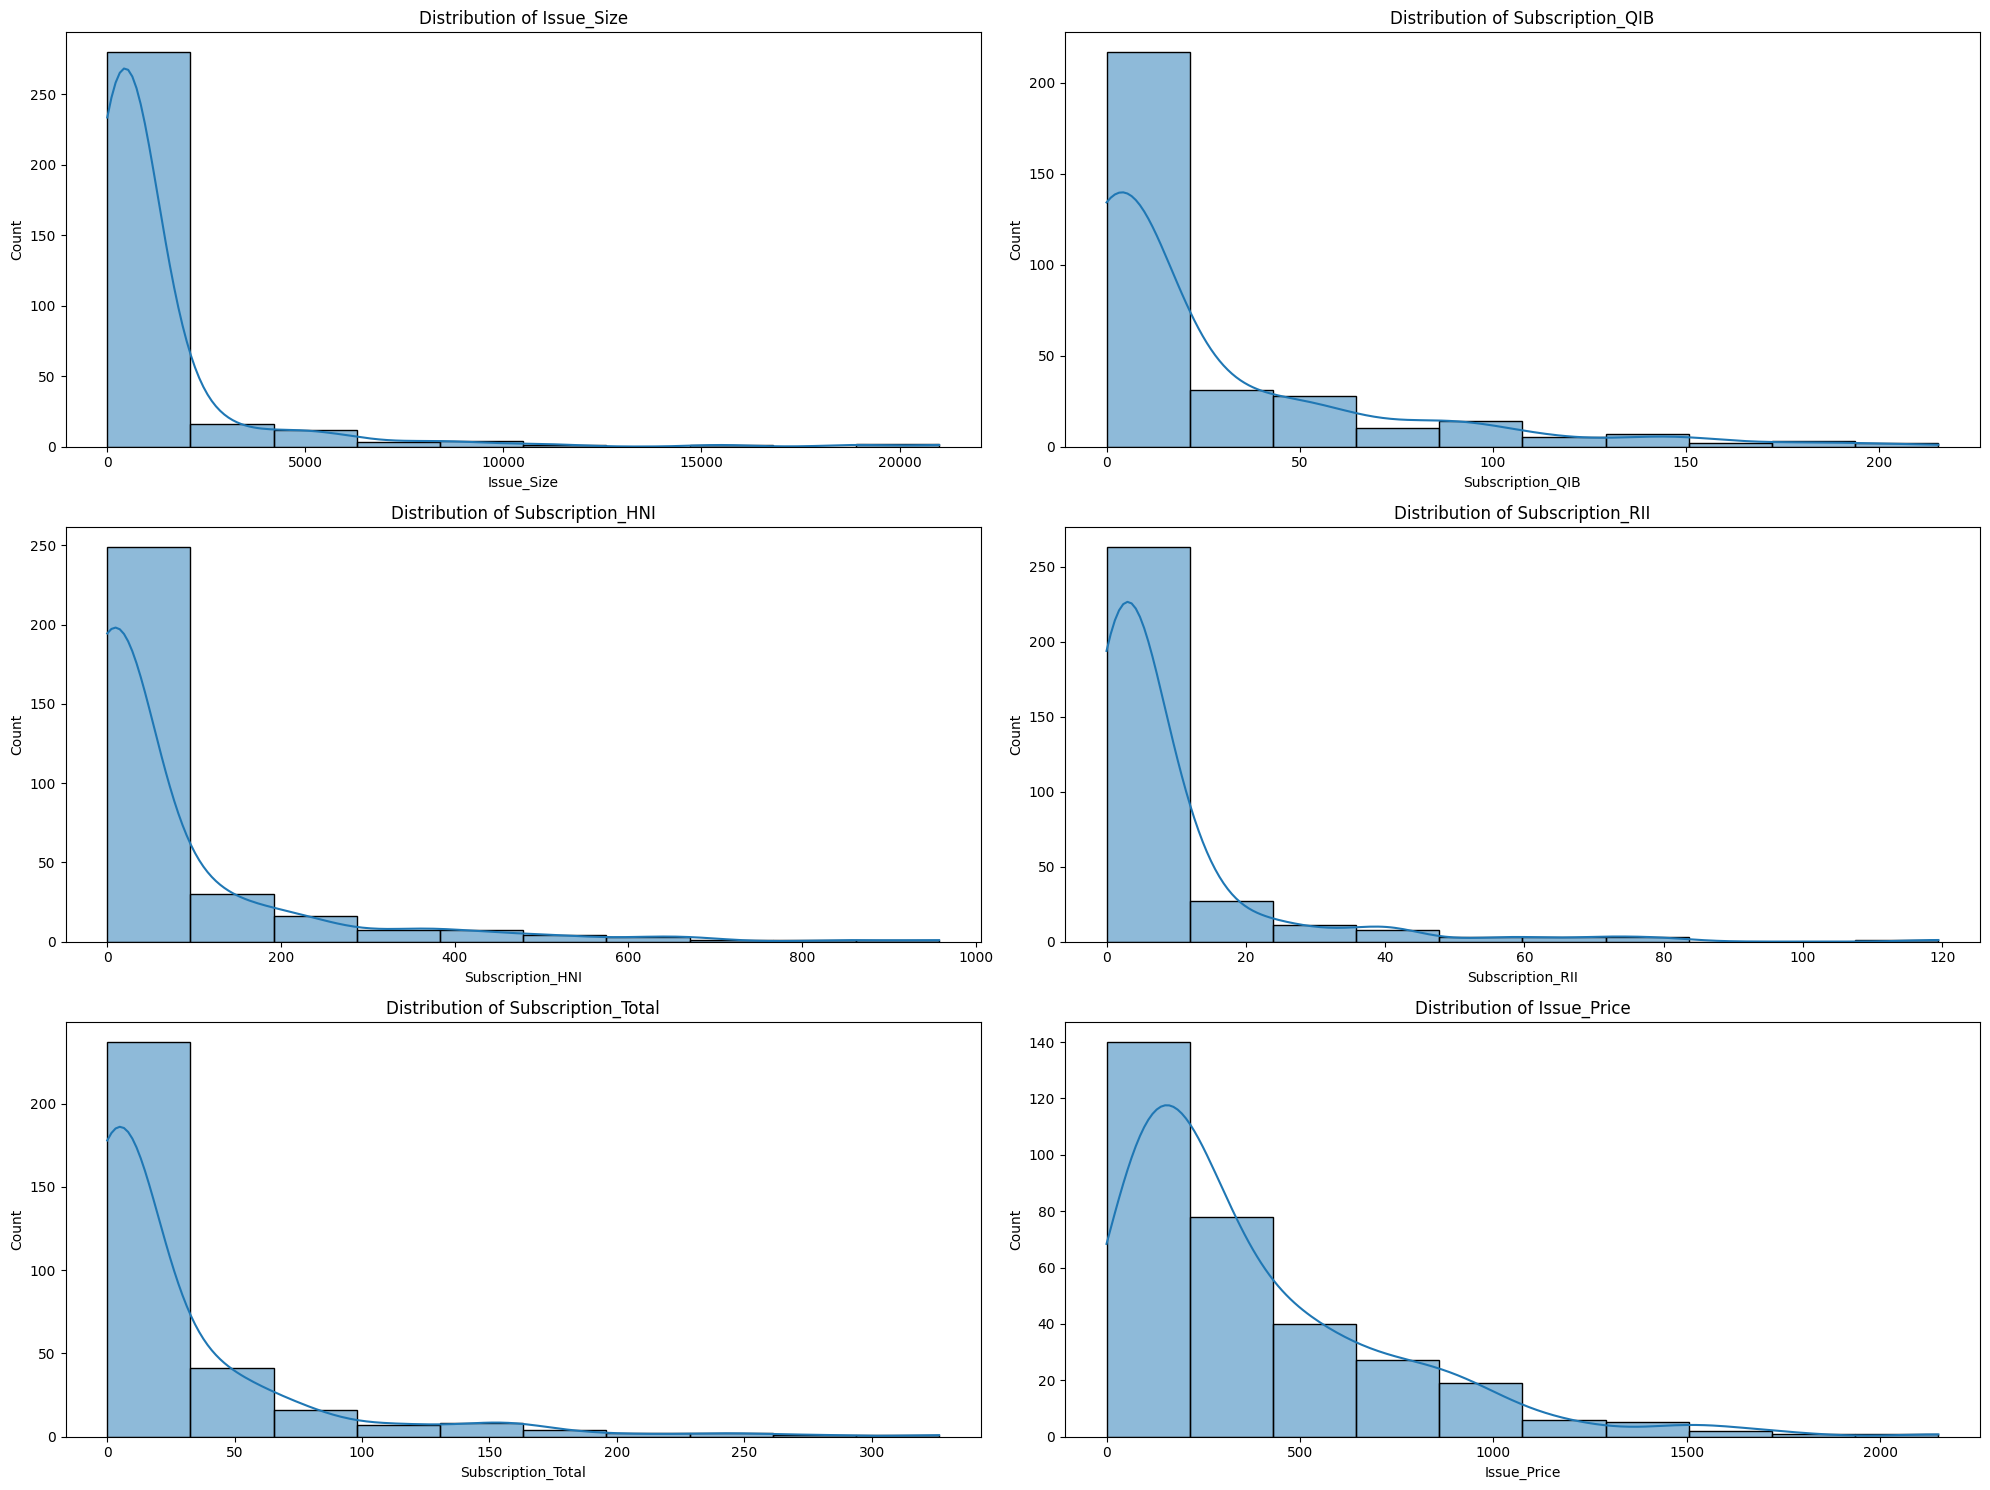

In [23]:
distribution_pt1 = df_clean[['Issue_Size', 'Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', 'Subscription_Total', 'Issue_Price']]

n_rows = 3
n_cols = 2

# generating first group distribution visualization
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 15))
axes = axes.flatten()

for i, col in enumerate(distribution_pt1.columns):
    if distribution_pt1[col].dtype == 'object' or distribution_pt1[col].nunique() < 6:  # Check for categorical data
        sns.countplot(data=distribution_pt1, x=col, ax=axes[i])
    else:
        sns.histplot(data=distribution_pt1, x=col, ax=axes[i], bins=10, kde=True)

    axes[i].set_title(f'Distribution of {col}')

for j in range(i + 1, n_rows * n_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

The repeated pattern in the distributions above shows us that the majority of IPOs have low subscription amounts, smaller issue sizes, and medium issue prices, while each category has a few extremely high values. While this helps us better understand more details of the IPO market in India, these high values (outliers) and lopsided (skewed) distributions would not do well in our model. Our model would get so distracted by the abnormally high values, that it would miss the relationships between the lower scale values which make up the majority of the data. To prevent this, we will simply scale our these features, which helps to balance out the larger values, compared to the smaller ones.

Now, let's take a look at the distributions of our dummy variables for weekdays and months.

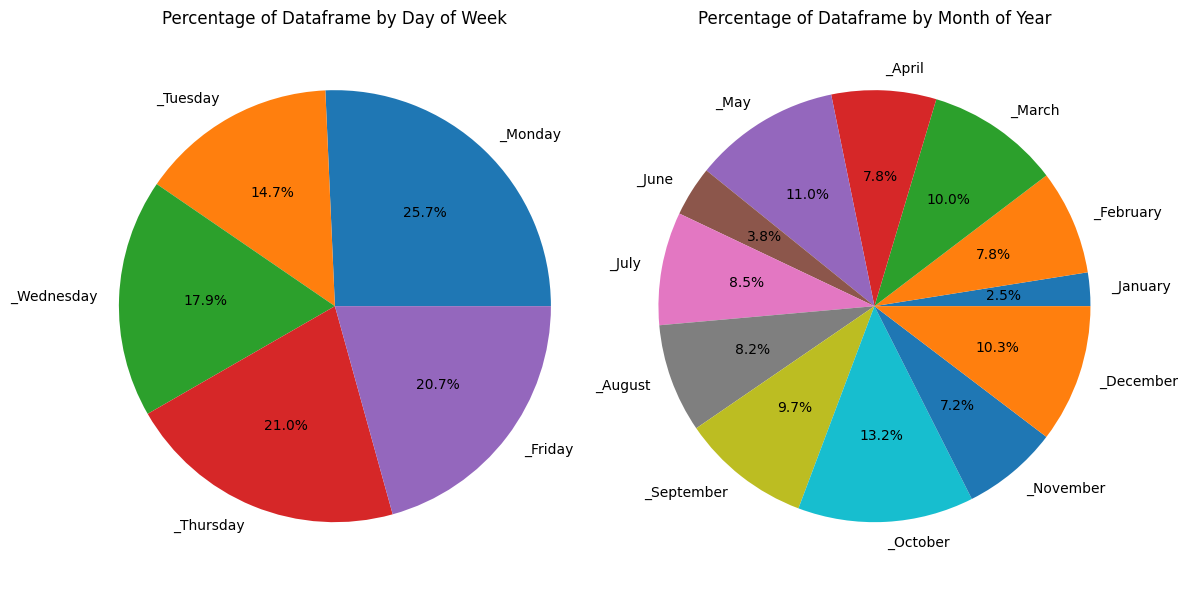

In [24]:
day_columns = ['_Monday', '_Tuesday', '_Wednesday', '_Thursday', '_Friday']
day_percentages = df_clean[day_columns].sum() / len(df) * 100

month_columns = ['_January', '_February', '_March', '_April', '_May', '_June', '_July', '_August', '_September', '_October', '_November', '_December']
month_percentages = df_clean[month_columns].sum() / len(df) * 100

# Create a figure and axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# First pie chart
ax1.pie(day_percentages, labels=day_percentages.index, autopct='%1.1f%%')
ax1.set_title('Percentage of Dataframe by Day of Week')

# Second pie chart
ax2.pie(month_percentages, labels=month_percentages.index, autopct='%1.1f%%')
ax2.set_title('Percentage of Dataframe by Month of Year')

# Ensure the pie charts are drawn as circles
ax1.axis('equal')
ax2.axis('equal')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

In examining the outcome above, we notice that there indeed are certain weekdays and months that occur more than others. We can see that Monday holds the highest percentage in the weekday category, while October holds the highest percentage in the month category. This helps us to see times of the week and year that might be more prone to have IPO listings.

These distribution visualizations have given us a good idea of what our features are doing across the dataset. Next, we want to look at what our feature are doing when the IPO results in positive gain versus when it results in a negative loss. Once again, we are going to visualize the two halves of our data seprately, and make our observations after each one. Let's start with visualizing our first group of featues across gains and losses in the code below.

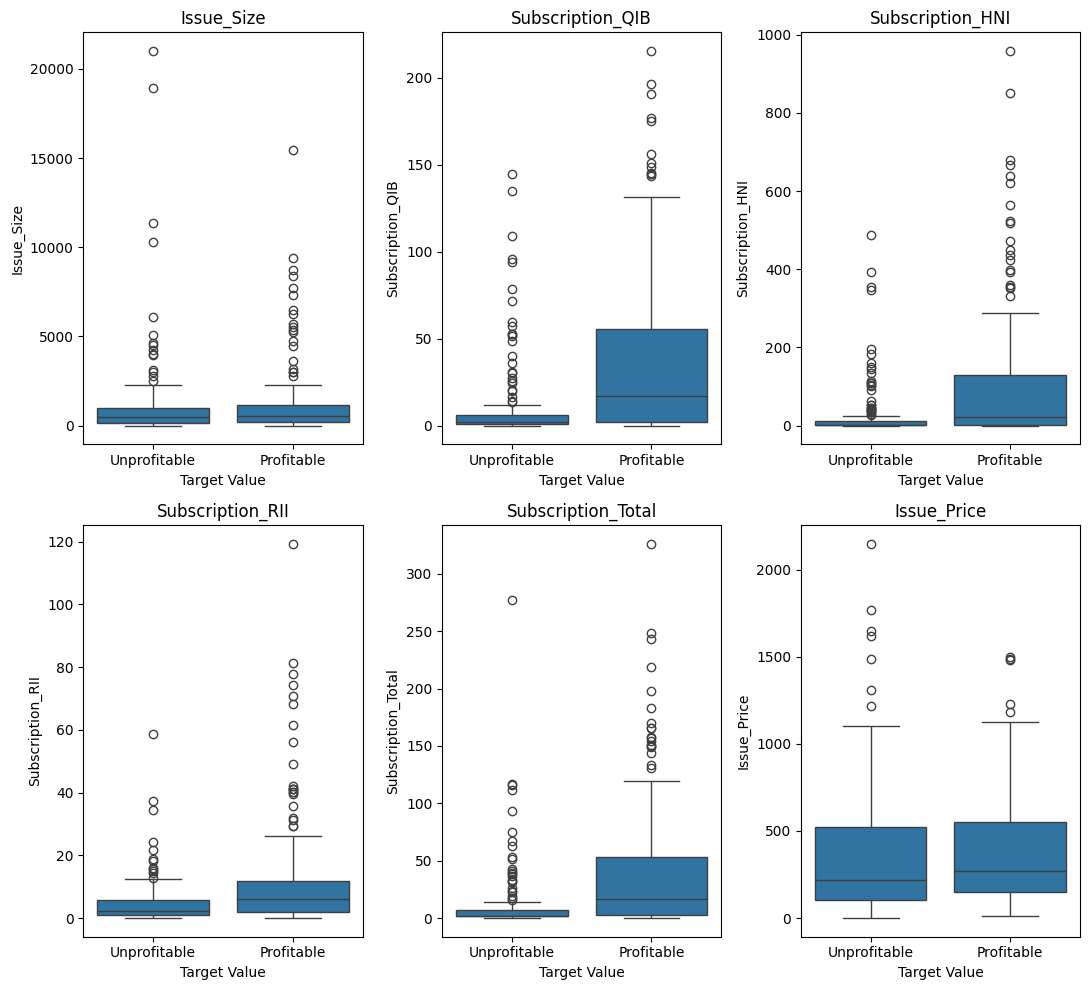

In [25]:
def create_boxplot_grid(df, columns, target_column):
    # Number of columns in the plot grid
    n_cols = 3  # Fixed to 3 columns
    n_rows = 2  # Fixed to 2 rows
    
    # Create the figure and subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(11, 10))
    
    # Flatten the axes for easier indexing
    axes = axes.flatten()
    
    # Create box plots for each feature
    for i, column in enumerate(columns):
        # Create a dataframe with the feature and target
        plot_data = pd.DataFrame({
            'Value': df[column],
            'Target': df[target_column]
        })
        
        # Create the box plot
        sns.boxplot(x='Target', y='Value', data=plot_data, ax=axes[i])
        
        # Set title and labels
        axes[i].set_title(f'{column}')
        axes[i].set_xlabel('Target Value')
        axes[i].set_ylabel(column)
        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(['Unprofitable', 'Profitable'])
    
    # Adjust layout
    plt.tight_layout()
    plt.show()


create_boxplot_grid(df_clean, ['Issue_Size', 'Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', 'Subscription_Total', 'Issue_Price'], 'Listing_Gains_Profit')

Throughout all our observations up to this point, the data has slowly been painting a picture of the information it holds. Now, as we study the results above, we can see the details really start falling into place. We observe from the box plots of the `Issue_Size` and `Issue_Price` features, that the size and original price of an IPO doesn't matter when it comes to weather or not it will be profitable. The subscription features however, show us that the environment of the market is everything. If the investors are feeling excited about an IPO, it will be successful. The demeand and energy of the market, represented by the eagerness of investors to oversubscribe, will determine the outcome of gain or loss. This tells us that these features detailing different types of subscriptions will be very important to our model. If our model is able to learn the relationships between subscriptions and profitable IPOs, it's accuracy should boost significantly.

Next, we want to examine the day and month features. We will be looking at the number of times each weekday and month occured when the IPO was profitable, and when it wasn't. This will help us to see if the market demand changes at all during different times of the week or the year.

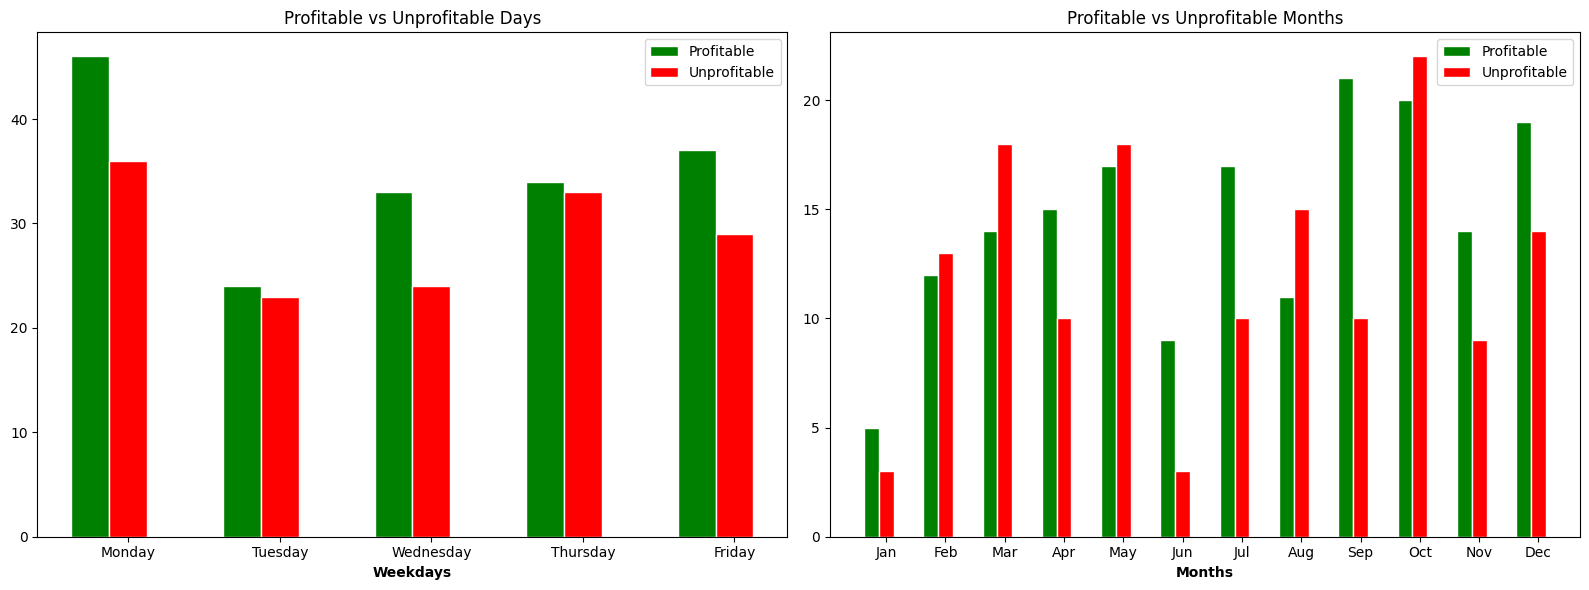

In [26]:
profitable_data = df_clean[df_clean['Listing_Gains_Profit'] == 1]
unprofitable_data = df_clean[df_clean['Listing_Gains_Profit'] == 0]

day_columns = ['_Monday', '_Tuesday', '_Wednesday', '_Thursday', '_Friday']
profitable_day_sums = [profitable_data[col].sum() for col in day_columns]
unprofitable_day_sums = [unprofitable_data[col].sum() for col in day_columns]

month_columns = ['_January', '_February', '_March', '_April', '_May', '_June', '_July', '_August', '_September', '_October', '_November', '_December']
profitable_month_sums = [profitable_data[col].sum() for col in month_columns]
unprofitable_month_sums = [unprofitable_data[col].sum() for col in month_columns]

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Weekdays
barWidth = 0.25
bars1_day = profitable_day_sums
bars2_day = unprofitable_day_sums

# Bar positions for weekdays
r1 = np.arange(len(bars1_day))
r2_day = r1 + barWidth

# Weekdays plot
ax1.bar(r1, bars1_day, color='green', width=barWidth, edgecolor='white', label='Profitable')
ax1.bar(r2_day, bars2_day, color='red', width=barWidth, edgecolor='white', label='Unprofitable')

# Weekdays x-axis settings
ax1.set_xlabel('Weekdays', fontweight='bold')
ax1.set_xticks(r1 + barWidth)
ax1.set_xticklabels(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
ax1.legend()
ax1.set_title('Profitable vs Unprofitable Days')

# Plot 2: Months
bars1_month = profitable_month_sums
bars2_month = unprofitable_month_sums

# Bar positions for months
r2 = np.arange(len(bars1_month))
r2_month = r2 + barWidth

# Months plot
ax2.bar(r2, bars1_month, color='green', width=barWidth, edgecolor='white', label='Profitable')
ax2.bar(r2_month, bars2_month, color='red', width=barWidth, edgecolor='white', label='Unprofitable')

# Months x-axis settings
ax2.set_xlabel('Months', fontweight='bold')
ax2.set_xticks(r2 + barWidth)
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax2.legend()
ax2.set_title('Profitable vs Unprofitable Months')

# Adjust layout and display
plt.tight_layout()
plt.show()

From the output above, we can see that there are a few days and months that might end up being of use to us. In our dataset we do not have any additional information pertaining to events that might explain why certain days and months would have more profitable gains than others. Whatever the reason, the visualizations above suggest that the eagerness of investors seems higher on days like Monday, Wednesday, and Friday, and on months like July, September, and December.

### Feature Selection - Correlations

Now, we are going to examine the correlation values between our feature canidates and our target feature. The assessment of the calculated correlation values will help us determine and finalize our feature selection. We will visualize these correlation values in the code below.

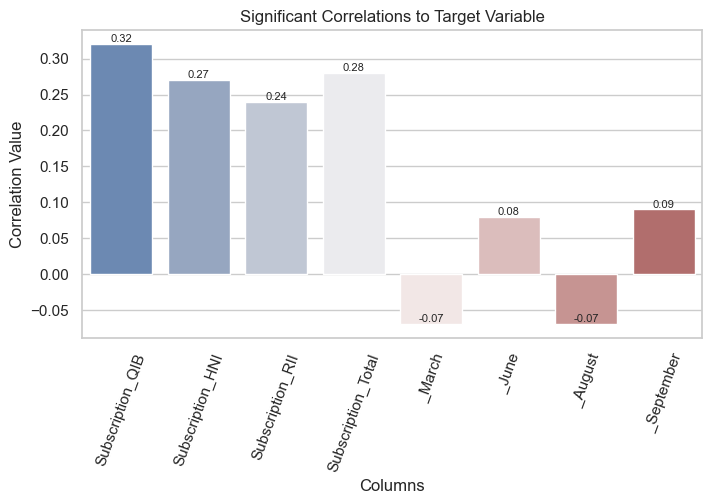

In [27]:
target_variable = 'Listing_Gains_Profit'

# Calculate and round the correlation values to two decimals
correlation_matrix = df_clean.corr()
correlation_matrix_rounded = correlation_matrix.round(2)

# Extract the target variable's correlations and filter the df correlations to contain those large enough to be significant
target_correlations = correlation_matrix_rounded[[target_variable]]
filtered_corr = target_correlations[(target_correlations[target_variable] > 0.05) |
                                    (target_correlations[target_variable] < -0.05)]

# Drop the target variable and 'area' column from the results
filtered_corr = filtered_corr.drop([target_variable])

# Prepare the df for plotting
filtered_corr.reset_index(inplace=True)
filtered_corr.columns = ['Column', 'Correlation value']  # Rename the columns for plotting

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4))

# Create a bar plot with updated parameters
bar_plot = sns.barplot(x='Column', y='Correlation value', hue='Column',
                       data=filtered_corr, palette='vlag', legend=False)

for i, v in enumerate(filtered_corr['Correlation value']):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

plt.xticks(rotation=70)
plt.title('Significant Correlations to Target Variable')
plt.xlabel('Columns')
plt.ylabel('Correlation Value')
plt.show()

In the visualization above, we filtered the correlation values to show only those that would be valueable enough to keep, anything over 0.05 or under -0.05. As we suspeceted all the subscription columns have a strong correlation to our target feature. We also see that four months, March, June, August, and September all had strong enough correlation values to make it past the filter. This is all very valuable information, that will aid us in making our final feature selection.

### Feature Selection - Final Decision

We have learned so much about our data up to this point. We have seen the importance of subscription amounts to show us the atmosphere of the market, and identified several months when IPOs might be more popular than in others. However, with all that we have learned, when we select our features, we must remember that our model could likely be able to find much smaller, yet still important, relationships that we were not able to see. With this in mind, we have decided to include `Issue_Size` and `Issue_Price` in our feature selection, even though there was not direct correlation between them and our target feature. Perhaps there is some kind of relationship between IPOs that are large in size and subscriptions amounts, or IPOs that have a high innitial price and subscriptions amounts.

Next, we have decided to not include the `Subscription_Total` feature in our selection. Yes, we realize that it has a strong relationship with our target feature. However it is also simply the `Subscription_QIB`, `Subscription_HNI`, and `Subscription_RII` features added together. This makes the information in `Subscription_Total` redunant, and would cause unnessary clutter in our model. That being said, we will state the obvious that we are going to include the `Subscription_QIB`, `Subscription_HNI`, and `Subscription_RII` features in our model. Lastly, we decided to add one month feature to our selection, September. 

Our final feature selection is as follows:

- `Issue_Size`
- `Issue_Price`
- `Subscription_QIB`
- `Subscription_HNI`
- `Subscription_RII`
- `_September`

### Model Foundations

We are now ready to take action towards actually building our model. Our first few steps will include:

- Defining our features and our target
- Splitting our data into training, validation, and testing poritons
- Scaleing each set to compensate for heavily skewed feature values

Let's begin in the code below!

In [28]:
# defining our features and target
features = ['Issue_Size', 'Issue_Price', 'Subscription_QIB', 'Subscription_HNI', 'Subscription_RII', '_September']
target_variable = 'Listing_Gains_Profit'

X = df_clean[features].copy()
y = df_clean[target_variable].copy()

print(f"Feature Data: {X.shape}")
print(f"Target Data: {y.shape}")

Feature Data: (319, 6)
Target Data: (319,)


Now that we've assigned our features and target to their own variables, we can now proceed with splitting the data into three different sections. We want to split our data into a training section, a validation section, and a testing section. The training section will contain 60% of the data, the validation section 20%, and the test section 20%. In the code below, we will start by separating our testing set from the rest of the data. Then, we will divide the rest of the data into our validation and training sets.

In [29]:
# First split: separate test set (20%)
X_temporary, X_test, y_temporary, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Second split: divide remaining data into training (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temporary, y_temporary, test_size=0.25, stratify=y_temporary, random_state=42
)

print(f"Total samples: {len(X)}")
print(f"Training set size: {len(X_train)} ({len(X_train)/len(X)*100:.2f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X)*100:.2f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(X)*100:.2f}%)")

print(f"\nPercentages of profitable IPOs (Are the splits even?):")
print(f"Training set: {y_train.mean():.1%}")
print(f"Validation set: {y_val.mean():.1%}")
print(f"Test set: {y_test.mean():.1%}")

Total samples: 319
Training set size: 191 (59.87%)
Validation set size: 64 (20.06%)
Test set size: 64 (20.06%)

Percentages of profitable IPOs (Are the splits even?):
Training set: 54.5%
Validation set: 54.7%
Test set: 54.7%


In the code above, we have successfully split our data in to three sets, testing, training, and validation. Next, we want to scale each of these sets. Scaling puts all the feature values on the same scale. This causes the model to be able to see relationships in the data without being distracted by extremely high values in the unbalanced feature columns. We will scale each set in the code below.

In [30]:
# intializing and fitting scaler
scaler = StandardScaler()
scaler.fit(X_train)

# scale transforming datasets
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# converting back to dataframe format
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

In [31]:
print(f"Training Data: {X_train_scaled.shape}")
print(f"Validation Data: {X_val_scaled.shape}")
print(f"Testing Data: {X_test_scaled.shape}")

print(f"\nTraining data stats post scaling (if performed correctly, stats should be ~0 mean, ~1 std):")
print(f"  Means: {X_train_scaled.mean().round(3).values}")
print(f"  Standard deviations: {X_train_scaled.std().round(3).values}")

print(f"\nValidation data means post scaling (will be slightly different):")
print(f"  Means: {X_val_scaled.mean().round(3).values}")

print(f"\nTest data means post scaling (will be slightly different):")
print(f"  Means: {X_test_scaled.mean().round(3).values}")

Training Data: (191, 6)
Validation Data: (64, 6)
Testing Data: (64, 6)

Training data stats post scaling (if performed correctly, stats should be ~0 mean, ~1 std):
  Means: [0. 0. 0. 0. 0. 0.]
  Standard deviations: [1.003 1.003 1.003 1.003 1.003 1.003]

Validation data means post scaling (will be slightly different):
  Means: [ 0.025 -0.243 -0.026 -0.114  0.069  0.149]

Test data means post scaling (will be slightly different):
  Means: [ 0.265  0.165 -0.071  0.007  0.154  0.092]


After we scaled our three data partitions, we ran a quick verification test on the data in the outcome above. We can see that the scale calulations performed correctly, and our data is now ready to continue on it's journey towards our model!

### PyTorch Tensors Conversion

Since we are going to be building a PyTorch model, we will need to adjust our data so the model can use it. We need to transpose our data into the language that our model will be working with, tensors. We will perform this conversion in the code below, also specifiying the data type as float32, which is the preferable datatype for our model.

In [32]:
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

Now that we have converted the data itself, we want to also convert it's format, by arranging it into a TensorDataset. This matches each set of features with its correct target values, and places each pair in its own organized collection. We will complete this work in the code below.

In [33]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

print(f"Tensor datasets:")
print(f"Training dataset: {len(train_dataset)} samples")
print(f"Validation dataset: {len(val_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")

Tensor datasets:
Training dataset: 191 samples
Validation dataset: 64 samples
Test dataset: 64 samples


### DataLoaders

Next, we will set up our DataLoaders. DataLoaders split our data up into small, organized, magangeable pieces. We will use the peices from each set (training, validation, testing), later when we run our model. As each of the smaller chucks of data are run through our model, it is given the opportunity to learn lots different kinds of relationships that our data contains.

In the code below, we will specify each small batch of data to contain 16 samples. 16 samples is an amount that is small enough to keep our memory footprint lean, but substantive enough to generate smooth, dependable gradient updates. You'll also notice that we include an important difference bewteen the Training DataLoader and the other two. When we define the Training DataLoader, will specify the `shuffle` parameter as True, while in the Validation and Testing DataLoaders, this parameter will be set to False. We do this because when the Training data is shuffled, it causes the model to see a different combination each time the data is circulated through, helping it to catch more relationship details. However, we do not want to shuffle the Validation or Testing data because we want something consistant to test our model against. This will help us to get more consistant results, and a better idea of how our model is actually performing.

In [34]:
# Training loader: shuffle=True
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# Validation loader: shuffle=False
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Test loader: shuffle=False
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"# of Training batches: {len(train_loader)}")
print(f"# of Validation batches: {len(val_loader)}")
print(f"# of Test batches: {len(test_loader)}")

# of Training batches: 12
# of Validation batches: 4
# of Test batches: 4


Above, we can see the number of data batches that our DataLoaders formed for each of our three sets of data. Recall that each batch has a maximum of 16 samples in it. With the above outcome, it seems that DataLoader did what we expected. However, let's examine a sample batch of training data below to verify this before we move on.

In [35]:
# Sample batch for the training loader examination
for batch_features, batch_targets in train_loader:
    print("\033[1m" + "Sample Batch:" + "\033[0m")
    print(f"  - shape of features: {batch_features.shape}")
    print(f"  - shape of targets: {batch_targets.shape}")
    print(f"  - features dtype: {batch_features.dtype}")
    print(f"  - targets dtype: {batch_targets.dtype}")
    print(f"  - target values: {batch_targets.tolist()}")
    print(f"  - # of profitable IPOs: {(batch_targets == 1).sum().item()}/{len(batch_targets)}")
    break  # Only sampling the first batch

Sample Batch:
  - shape of features: torch.Size([16, 6])
  - shape of targets: torch.Size([16])
  - features dtype: torch.float32
  - targets dtype: torch.float32
  - target values: [1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0]
  - # of profitable IPOs: 7/16


From these results, it's clear that our data batches are indeed doing well. We are now ready to build our model!

### Model Architecture Design

We have at last come to building the model itself! In this next step, we will be constructing the intellectual foundation of our model. This is the process by which we express how we want our model to go from recieving the information in our selected features, to making an actual prediction for each instance, that the IPO will be profitable or not. As we mentioned before, this is where our model will learn the realationships of the data we train it on. Through it's learning process, it will probably even find small relationships in the data that we could not see in our EDA (Exploratory Data Analysis). More specifically, in the code below, we will be building the framework in which we want the model to process the data, then the model will do the learning on its own, as the training data cycles through.

In [36]:
input_size = X_train_tensor.shape[1]  # Number of features
print(f"Our model needs to handle {input_size} input features")

# building our neural network
model = nn.Sequential(
    # First hidden layer: from input features to 64 neurons
    nn.Linear(input_size, 64),
    nn.ReLU(),

    # Second hidden layer: 64 to 32 (starting to funnel down)
    nn.Linear(64, 32),
    nn.ReLU(),

    # Third hidden layer: 32 to 16 (continuing the funnel)
    nn.Linear(32, 16),
    nn.ReLU(),

    # Fourth hidden layer: 16 to 8 (continuing the funnel)
    nn.Linear(16, 8),
    nn.ReLU(),

    # Output layer: 8 to 1 (our final prediction)
    nn.Linear(8, 1),
    nn.Sigmoid()  # Sigmoid gives us a probability between 0 and 1
)

print(model)

Our model needs to handle 6 input features
Sequential(
  (0): Linear(in_features=6, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=16, bias=True)
  (5): ReLU()
  (6): Linear(in_features=16, out_features=8, bias=True)
  (7): ReLU()
  (8): Linear(in_features=8, out_features=1, bias=True)
  (9): Sigmoid()
)


### Model Examination

We've created our model so that it accepts input values, which are them multiplied by weights, combined with biases, and passed through an activation function. This activiatio function, ReLU, is a large part of what distinguishes this kind of model from the typical linear regression model. It adds the color and flavor of non-linearity to our model, which is what enables our model to learn those small yet meaningful relationships between our features and target values. The ability to learn these reationships is one of the components that will play a noteworthy role in the success rate of our model. 

Now that we have constructed our model, let's look a bit closer at its inner workings.

In [37]:
# number of parameters our model has to learn
total_params = sum(param.numel() for param in model.parameters())
trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# investigating each layer to locate complexity
print("\nParameter breakdown by layer:")
for i, layer in enumerate(model):
    if isinstance(layer, nn.Linear):
        layer_params = sum(param.numel() for param in layer.parameters())
        print(f"  Layer {i} (Linear): {layer_params:,} parameters")

Total parameters: 3,201
Trainable parameters: 3,201

Parameter breakdown by layer:
  Layer 0 (Linear): 448 parameters
  Layer 2 (Linear): 2,080 parameters
  Layer 4 (Linear): 528 parameters
  Layer 6 (Linear): 136 parameters
  Layer 8 (Linear): 9 parameters


We can see that the above counts of parameters are first model wide, and then from layer to layer. These sums of parameters are simply the amounts of internal variables the model uses to make predictions. These are the weights and bias values we mentioned earlier. 

So far our model is looking good, so let's go ahead and execute a test run of our model. We want to ensure that it can indeed function with data as we intended.

In [38]:
# testing our model with a small batch of data
model.eval()
with torch.no_grad():
    for batch_features, batch_targets in train_loader:
        test_outputs = model(batch_features)

        print(f"Input batch shape: {batch_features.shape}")
        print(f"Output batch shape: {test_outputs.shape}")
        print(f"Sample predictions: {test_outputs.squeeze()[:5].tolist()}")
        print(f"Sample actual targets: {batch_targets[:5].tolist()}")
        break

Input batch shape: torch.Size([16, 6])
Output batch shape: torch.Size([16, 1])
Sample predictions: [0.4776958227157593, 0.4784206748008728, 0.477666974067688, 0.4776245653629303, 0.47787195444107056]
Sample actual targets: [0.0, 0.0, 1.0, 1.0, 1.0]


Our model successfully processed a batch of 16 IPOs and produced probability predictions between 0 and 1. You'll notice that the predictions are all around `.54` **(Check this at the end of project, correct number)**, but this is not without reason or indicating a problem. These values are simply communicating to us that our model is leaning towards predicting profitable IPOs. However, this is not concerning because our model has not been trained yet. It has been given no understanding of our data enabling it to make correct predictions. Keeping this in mind, we are pleased to have prediction values around `0.5`, which confirms that our untrained model is working as it should. Lastly, these prediction values will serve as the baseline from which we can watch our model improve. We will be able to see these values separate more, with the predictions of profitable IPOs being closer to 1, and unprofitable IPO predictions being closer to 0, as our model gains a better knowledge of our data.

### Model Training

We are now ready to train our model. We will first begin the process by defining our loss function and optimizer. Then, we will initialize two lists in which we will keep track of the accuracies our model achieves when used on the training data and the verification data. Next, we will build the "school" in which our model will learn the data, relationships, and how to make accurate predictions. We will do this by running the training data through our model lots of times, allowing the model to identify it's mistakes, correct itself, and do better in the next round. Each time all of our training samples run through the model, that is called an epoch. We will train our model on 100 epochs. In other words, our model gets 100 chances to see all the training data, to learn about it. At the end of each epoch, we will calculate the accuracy our model is making on the training and validation data after what it has learned from the most recent epoch. We will put all these accuracy values into their respective lists, and lastly, use these lists to visualize how our model learned and improved throughout its learning.

In [39]:
# defining our loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy for our yes/no predictions
optimizer = optim.Adam(model.parameters(), lr=0.00075)

# initialize two accuracy lists
train_accuracies = []
val_accuracies = []

In [40]:
num_epochs = 100

for epoch in range(num_epochs):
    # Training phase - model learns from data
    model.train()

    for batch_features, batch_targets in train_loader:
        optimizer.zero_grad()                            # Clear old gradients
        outputs = model(batch_features).squeeze()        # Forward pass
        loss = criterion(outputs, batch_targets)         # Calculate loss
        loss.backward()                                  # Backward pass
        optimizer.step()                                 # Update weights

    # Evaluation phase - check how model is doing
    model.eval()
    with torch.no_grad():
        # Check training accuracy
        train_outputs = model(X_train_tensor).squeeze()
        train_predictions = (train_outputs > 0.5).float()
        train_accuracy = (train_predictions == y_train_tensor).float().mean().item() * 100

        # Check validation accuracy
        val_correct = 0
        val_total = 0
        for val_features, val_targets in val_loader:
            val_outputs = model(val_features).squeeze()
            val_predictions = (val_outputs > 0.5).float()
            val_correct += (val_predictions == val_targets).sum().item()
            val_total += val_targets.size(0)
        val_accuracy = (val_correct / val_total) * 100

        # Save our accuracies for plotting
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

print(f"Final training accuracy: {train_accuracies[-1]:.1f}%")
print(f"Final validation accuracy: {val_accuracies[-1]:.1f}%")

Final training accuracy: 81.7%
Final validation accuracy: 60.9%


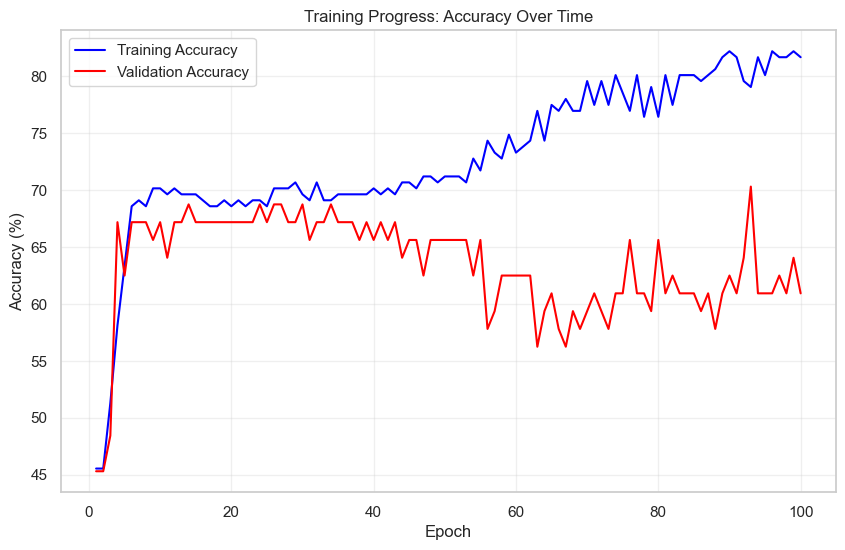

Best validation accuracy: 70.3% (achieved at epoch 93)
Final gap between training and validation: 20.7 percentage points
⚠️ Large gap suggests possible overfitting - validation accuracy much lower than training


In [41]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy', color='blue')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy', color='red')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Progress: Accuracy Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Let's also see the best performance we achieved
best_val_accuracy = max(val_accuracies)
best_epoch = val_accuracies.index(best_val_accuracy) + 1

print(f"Best validation accuracy: {best_val_accuracy:.1f}% (achieved at epoch {best_epoch})")

# Check for potential overfitting
final_gap = train_accuracies[-1] - val_accuracies[-1]
print(f"Final gap between training and validation: {final_gap:.1f} percentage points")

if final_gap > 10:
    print("⚠️ Large gap suggests possible overfitting - validation accuracy much lower than training")
elif final_gap < 5:
    print("✅ Small gap suggests good generalization - model performs similarly on both sets")
else:
    print("🤔 Moderate gap - model might benefit from some regularization")

### Debrief

**(Check this at the end of project, correct numbers)** In the plot above, we can see the progress of our model as it went through it's training journey. The plot shows that the model's accuracy on both the training and validation datasets steadily increased together until around epoch 20. After epoch 20, the training accuracy continues to increase towards 80%, while the validation accuracy hovers beneath 70%. 

Remember that the model was educated on the training dataset, meaning that the accuracy values for the validation dataset shows how the model was improving or not improving with data it had not seen before. Imagine the training loop we just put our model through as a school. The testing data serves as a regular day's teaching and class work. The validation data serves as the test at the end of each unit of material (1 epoch). By viewing both the training data accuracy and the validation accuracy, we can observe the "grades" of our model on the weekly assignments versus the unit tests. 

What does this plot tell us about our model? This outcome makes it very clear that at a certain point, our model is no longer learning the general patterns of the data, but instead memorizing the data it is being trained on. It's as if our model is memorizing only the answers to the weekly assignment questions, not learning the concepts themselves, then failing the unit tests.

When this happens, it is called overfitting. To remedy this, we will build a new regularized model in which we ensure that the model learns the details and concepts of the data. We will also set the trainer an indicator to stop training the model if it's no longer learning and improving, helping to prevent overfitting. Let's build our new model in the code below.

In [42]:
input_size = X_train_tensor.shape[1]

reg_model = nn.Sequential(
    # First layer
    nn.Linear(input_size, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.25),

    # Second layer
    nn.Linear(64, 32),
    nn.BatchNorm1d(32),
    nn.ReLU(),
    nn.Dropout(0.125),

    # Third layer
    nn.Linear(32, 16),
    nn.BatchNorm1d(16),
    nn.ReLU(),
    
    # Fourth hidden
    nn.Linear(16, 8),
    nn.ReLU(),

    # Output layer
    nn.Linear(8, 1),
    nn.Sigmoid()  # Sigmoid gives us a probability between 0 and 1
)

print(f"Total parameters: {sum(param.numel() for param in reg_model.parameters()):,}")
print(reg_model)

Total parameters: 3,425
Sequential(
  (0): Linear(in_features=6, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.25, inplace=False)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.125, inplace=False)
  (8): Linear(in_features=32, out_features=16, bias=True)
  (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Linear(in_features=16, out_features=8, bias=True)
  (12): ReLU()
  (13): Linear(in_features=8, out_features=1, bias=True)
  (14): Sigmoid()
)


In our new model above, you can see that we added a few items that will hopefully help prevent overfitting. The Batch Normalization (BatchNorm1d) layers force training to stabilize and learning rates to be higher by normalizing the inputs of each layer. The Dropout layers cause the model to loose bits of information here and there, which forces the model to think differently and find the small relationships it wouldn't have found otherwise. We also adjusted the Dropout rates to be the appropriate sizes for the different sized layers.

Now that our new regularized model is ready, we will go ahead and train it. As we mentioned before, we will place a limiter (patience) on our training loop that ends training if our model is no longer improving.

In [43]:
# Same setup as before for loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(reg_model.parameters(), lr=0.00075)

# Early stopping setup
best_val_accuracy = 0
patience = 20
patience_counter = 0
best_model_state = None

# Tracking our progress
reg_train_accuracies = []
reg_val_accuracies = []

print("Training will stop if validation accuracy doesn't improve for", patience, "consecutive epochs")

Training will stop if validation accuracy doesn't improve for 20 consecutive epochs


In [44]:
max_epochs = 100

for epoch in range(max_epochs):
    # Training phase - same as before
    reg_model.train()

    for batch_features, batch_targets in train_loader:
        optimizer.zero_grad()
        outputs = reg_model(batch_features).squeeze()
        loss = criterion(outputs, batch_targets)
        loss.backward()
        optimizer.step()

    # Evaluation phase
    reg_model.eval()
    with torch.no_grad():
        # Training accuracy
        train_outputs = reg_model(X_train_tensor).squeeze()
        train_predictions = (train_outputs > 0.5).float()
        train_accuracy = (train_predictions == y_train_tensor).float().mean().item() * 100

        # Validation accuracy
        val_correct = 0
        val_total = 0
        for val_features, val_targets in val_loader:
            val_outputs = reg_model(val_features).squeeze()
            val_predictions = (val_outputs > 0.5).float()
            val_correct += (val_predictions == val_targets).sum().item()
            val_total += val_targets.size(0)
        val_accuracy = (val_correct / val_total) * 100

        # Save our progress
        reg_train_accuracies.append(train_accuracy)
        reg_val_accuracies.append(val_accuracy)

        # Early stopping logic
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model_state = copy.deepcopy(reg_model.state_dict())
            patience_counter = 0
            print(f"Epoch {epoch+1}: New best validation accuracy: {val_accuracy:.1f}%")
        else:
            patience_counter += 1

        # Check if we should stop early
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (no improvement for {patience} epochs)")
            break

# Load the best model we found
reg_model.load_state_dict(best_model_state)
print(f"Loaded best model with validation accuracy: {best_val_accuracy:.1f}%")

Epoch 1: New best validation accuracy: 54.7%
Epoch 15: New best validation accuracy: 62.5%
Epoch 18: New best validation accuracy: 64.1%
Epoch 20: New best validation accuracy: 67.2%
Early stopping at epoch 40 (no improvement for 20 epochs)
Loaded best model with validation accuracy: 67.2%


### Model Comparison

So far, the results of our new model above look quite promising, and an improvement from the last model. To find out for sure if this model is indeed better, let's compare our two models below.

In [45]:
print("Model Comparison:")
print(f"Original model - Final training accuracy: {train_accuracies[-1]:.1f}%")
print(f"Original model - Final validation accuracy: {val_accuracies[-1]:.1f}%")
print(f"Original model - Gap: {train_accuracies[-1] - val_accuracies[-1]:.1f} percentage points")

print(f"\nRegularized model - Final training accuracy: {reg_train_accuracies[-1]:.1f}%")
print(f"Regularized model - Final validation accuracy: {reg_val_accuracies[-1]:.1f}%")
print(f"Regularized model - Gap: {reg_train_accuracies[-1] - reg_val_accuracies[-1]:.1f} percentage points")

improvement = reg_val_accuracies[-1] - val_accuracies[-1]
print(f"\nValidation accuracy improvement: {improvement:+.1f} percentage points")

Model Comparison:
Original model - Final training accuracy: 81.7%
Original model - Final validation accuracy: 60.9%
Original model - Gap: 20.7 percentage points

Regularized model - Final training accuracy: 69.1%
Regularized model - Final validation accuracy: 67.2%
Regularized model - Gap: 1.9 percentage points

Validation accuracy improvement: +6.2 percentage points


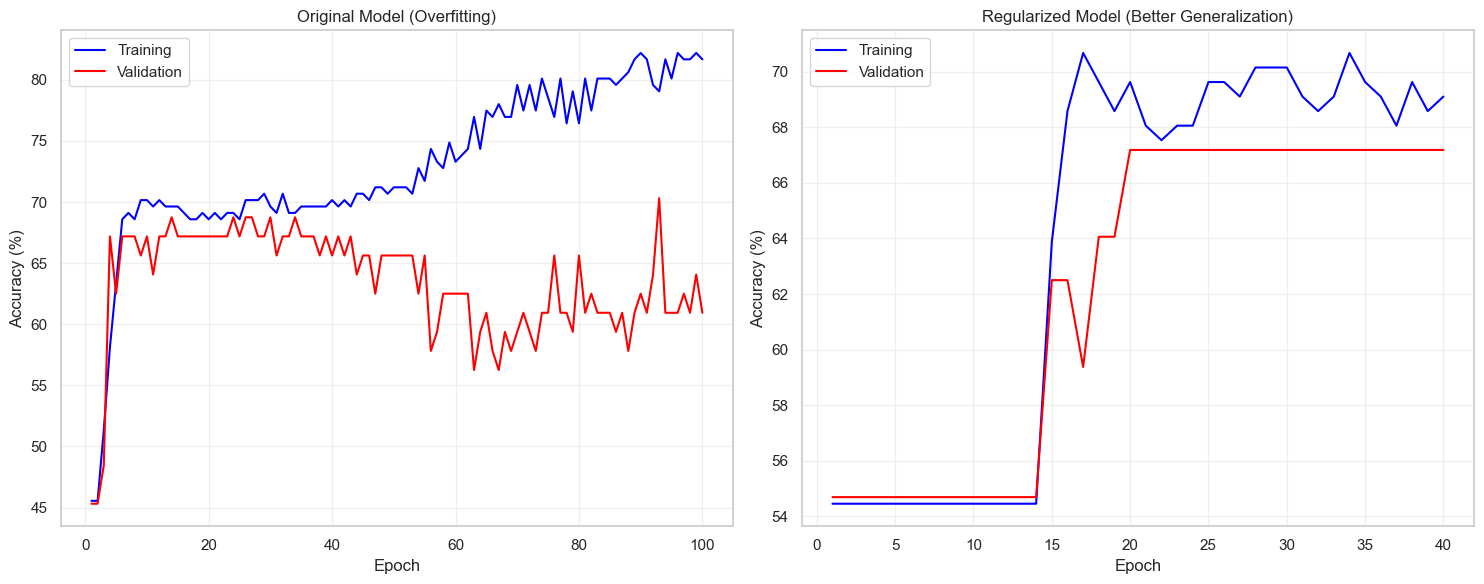

Outcome: Overfitting much improved


In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original model plot
ax1.plot(range(1, len(train_accuracies) + 1), train_accuracies, label='Training', color='blue')
ax1.plot(range(1, len(val_accuracies) + 1), val_accuracies, label='Validation', color='red')
ax1.set_title('Original Model (Overfitting)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Regularized model plot
ax2.plot(range(1, len(reg_train_accuracies) + 1), reg_train_accuracies, label='Training', color='blue')
ax2.plot(range(1, len(reg_val_accuracies) + 1), reg_val_accuracies, label='Validation', color='red')
ax2.set_title('Regularized Model (Better Generalization)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final thoughts on what we achieved
final_gap = reg_train_accuracies[-1] - reg_val_accuracies[-1]
if final_gap < 5:
    print("Outcome: Overfitting much improved")
elif final_gap < 10:
    print("Outcome: Overfitting moderately improved")
else:
    print("Outcome: Overfitting very little improved")

We can see that our new model is much better than the original. With the help of our patience limiter, our regularized model stopped training at epoch 48 (**double check at project end**), and the gap between the training accuracy and validation accuracy is much smaller than in our original model.

### Final Test

With our new model doing so well, we are ready to put it through the final analysis, running the testing data on it. Recall that the model has never seen this data, so this will truely and most honestly show how accurate our new model really is with brand new data.

In [47]:
reg_model.eval()  # Make sure we're in evaluation mode

with torch.no_grad():  # No need to compute gradients for evaluation
    # Get predictions on our test set
    test_outputs = reg_model(X_test_tensor).squeeze()
    test_predictions = (test_outputs > 0.5).float()  # Convert to binary predictions

predicted_profitable = test_predictions.sum().item()
actually_profitable = y_test_tensor.sum().item()

print(f"Regularized model tested on {len(y_test_tensor)} IPO instances")
print(f"Regularized model predictions: {int(predicted_profitable)} profitable, {int(len(test_predictions) - predicted_profitable)} unprofitable")
print(f"Actual IPO outcomes:  {int(actually_profitable)} profitable, {int(len(y_test_tensor) - actually_profitable)} unprofitable")

# Let's see some actual predictions vs reality
print(f"\nFirst 10 test predictions vs actual:")
for i in range(10):
    pred = "Profitable" if test_predictions[i] == 1 else "Not Profitable"
    actual = "Profitable" if y_test_tensor[i] == 1 else "Not Profitable"
    match = "✓" if test_predictions[i] == y_test_tensor[i] else "✗"
    print(f"  IPO {i+1}: Predicted {pred}, Actually {actual} {match}")

Regularized model tested on 64 IPO instances
Regularized model predictions: 34 profitable, 30 unprofitable
Actual IPO outcomes:  35 profitable, 29 unprofitable

First 10 test predictions vs actual:
  IPO 1: Predicted Not Profitable, Actually Profitable ✗
  IPO 2: Predicted Profitable, Actually Profitable ✓
  IPO 3: Predicted Not Profitable, Actually Not Profitable ✓
  IPO 4: Predicted Profitable, Actually Not Profitable ✗
  IPO 5: Predicted Profitable, Actually Profitable ✓
  IPO 6: Predicted Profitable, Actually Profitable ✓
  IPO 7: Predicted Profitable, Actually Profitable ✓
  IPO 8: Predicted Profitable, Actually Profitable ✓
  IPO 9: Predicted Not Profitable, Actually Profitable ✗
  IPO 10: Predicted Profitable, Actually Profitable ✓


### Troubleshooting

Above, we can clearly see that our model didn't have perfect accuracy on our testing data. However, our investment company won't simply be statisfied with an accuracy percentage. They will want to know the specefic areas in which our model is struggling. Let's use a confusion matrix to examine the specific details of our model's performance on the testing data.

In [48]:
cm = confusion_matrix(y_test_tensor.numpy(), test_predictions.numpy())
print("Confusion Matrix:")
print("                           Predicted Unprofitable       Predicted Profitable")
print(f"Actually Unprofitable               {cm[0,0]}                           {cm[0,1]}")
print(f"Actually Profitable                 {cm[1,0]}                           {cm[1,1]}")

# Extract the four key numbers
tn, fp, fn, tp = cm[0,0].item(), cm[0,1].item(), cm[1,0].item(), cm[1,1].item()

print(f"\nBreaking this down:")
print(f"True Negatives (TN): {tn} - Correctly predicted NOT profitable")
print(f"False Positives (FP): {fp} - Wrongly predicted profitable (Type I error)")
print(f"False Negatives (FN): {fn} - Wrongly predicted NOT profitable (Type II error)")
print(f"True Positives (TP): {tp} - Correctly predicted profitable")

print(f"\nOut of {tn + fp + fn + tp} total predictions:")
print(f"We got {tn + tp} right and {fp + fn} wrong")

type1 = fp
type2 = fn

print(f"\nOutstanding Error Type:")
if type1 > type2:
    print("Our model struggels most with Type I errors, predicting that IPOs will be profitable when they actually won't be.")
elif type2 > type1:
    print("Our model struggels most with Type II errors, predicting that IPOs will not be profitable when they actually will be.")
elif type2 == type1:
    print("Our model struggels with both Type I and Type II errors, (Type I) predicting some IPOs will be profitable when they actually won't be,")
    print("and (Type II) predicting other IPOs will not be profitable when they actually will be.")

Confusion Matrix:
                           Predicted Unprofitable       Predicted Profitable
Actually Unprofitable               17                           12
Actually Profitable                 13                           22

Breaking this down:
True Negatives (TN): 17 - Correctly predicted NOT profitable
False Positives (FP): 12 - Wrongly predicted profitable (Type I error)
False Negatives (FN): 13 - Wrongly predicted NOT profitable (Type II error)
True Positives (TP): 22 - Correctly predicted profitable

Out of 64 total predictions:
We got 39 right and 25 wrong

Outstanding Error Type:
Our model struggels most with Type II errors, predicting that IPOs will not be profitable when they actually will be.


### Conclusive Business Details

In the results above, we can see the exact points in which our model tends to struggle. This is all well and good, but an investor company will want answers to even more specific questions, such as "When the model says an IPO will be profitable, how often is it right?" or "Of all the profitable IPOs out there, how many did the model actually catch?". We can answer these kinds of questions below, by using the precision, recall, and accuracy calculations below.

In [50]:
# Calculate precision: Of all our "profitable" predictions, how many were right?
precision = tp / (tp + fp)

# Calculate recall: Of all actually profitable IPOs, how many did we find?
recall = tp / (tp + fn)

# Test accuracy - the overall percentage we got right
test_accuracy = (tn + tp) / (tn + fp + fn + tp) * 100

print("When the model says an IPO will be profitable, how often is it right?")
print(f"Precision: {precision:.3f} ({precision*100:.1f}%)")
print(f"  → When our model predicts 'profitable', it is right {precision*100:.1f}% of the time")

print(f"\nOf all the profitable IPOs out there, how many did the model actually catch?")
print(f"Recall: {recall:.3f} ({recall*100:.1f}%)")
print(f"  → Our model successfully identifies {recall*100:.1f}% of all profitable IPOs")

print(f"\nOf all the IPOs the model was not trained on, how many did the model correctly predict?")
print(f"Test Accuracy: {test_accuracy:.1f}%")
print(f"Validation Accuracy (best): {best_val_accuracy:.1f}%")
print(f"  → Our model correctly predicted {best_val_accuracy:.1f}% of all the IPOs in the validation data, and {test_accuracy:.1f}% of all the IPOs in the testing data.")

accuracy_diff = abs(test_accuracy - best_val_accuracy)
if accuracy_diff < 3:
    print(f"\nDifference between Testing and Validation accuracies = {accuracy_diff:.1f}%")
    print("This suggests our model generalizes well to completely new data.")
elif accuracy_diff < 7:
    print(f"\nDifference between Testing and Validation accuracies = {accuracy_diff:.1f}%")
    print("This suggests our model generalizes moderately to completely new data.")
else:
    print(f"\nDifference between Testing and Validation accuracies = {accuracy_diff:.1f}%")
    print("This suggests our model might still be overfitting a bit.")

When the model says an IPO will be profitable, how often is it right?
Precision: 0.647 (64.7%)
  → When our model predicts 'profitable', it is right 64.7% of the time

Of all the profitable IPOs out there, how many did the model actually catch?
Recall: 0.629 (62.9%)
  → Our model successfully identifies 62.9% of all profitable IPOs

Of all the IPOs the model was not trained on, how many did the model correctly predict?
Test Accuracy: 60.9%
Validation Accuracy (best): 67.2%
  → Our model correctly predicted 67.2% of all the IPOs in the validation data, and 60.9% of all the IPOs in the testing data.

Difference between Testing and Validation accuracies = 6.2%
This suggests our model generalizes moderately to completely new data.


Above, we have shown investors how often our model is correct, also giving them an idea of how often is is incorrect. While knowing how often a mistake might be made is good, it is even more important for an investor company to be able to know the kinds of mistakes that might happen, and what they could cost the company, espcially when making company decisions. As the final step in this project, we want to summarize the different kinds of mistakes that could happen when using our model, and what they would mean in relation to costs or consequences for the company.

In [ ]:
print("Business Impact Analysis:")
print("\n")

print("Error Type I - False Positives (FP):")
print(f"    - Number of cases: {fp}")
print("    - Mistake: Our model predicted an IPO as profitable, but it lost money")
print("    - Impact: Our business invests in an unprofitable IPO, and loses money")
print("    - Consequences: A direct injury to our business; we spent money on a failing invenstment")

print(f"\nError Type II - False Negatives (FN):")
print(f"    - Number of cases: {fn}")
print("    - Mistake: Our model predicted an IPO would fail, but it made a good profit")
print("    - Impact: Our business did not invest in a successful IPO")
print("    - Consequences: A missed business opportunity; our business could have made a profit but did not")

print(f"\Error Assessment:")
if fp > fn:
    print("The tendency of our model to make Type I Errors outweighs the tendency to make Type II Errors.")
    print("Business Interpretation: Our Investment Firm is spending money on failing investments, but not missing so many profitable business opportunities.")
    print("Possible Solution: Adjust the profitable to unprofitable threshold of our model above 0.5 (current), increasing sensitivity for truely profitable IPOs.")
elif fn > fp:
    print("The tendency of our model to make Type II Errors outweighs the tendency to make Type I Errors.")
    print("Business Interpretation: Our Investment Firm is missing many profitable business opportunities, but not spending money on failing investments.")
    print("Possible Solution: Adjust the profitable to unprofitable threshold of our model below 0.5 (current), allowing our model to catch as many profitable IPOs as possible.")
else:
    print("The tendency of our model to make Type I Errors is equal to its tendency to make Type II Errors.")
    print("Business Interpretation: Our Investment Firm is missing the same amount of profitable business opportunities as it is spending money on failing investments.")
    print("Possible Solution: No solution; the threshold of our model, 0.5, is balanced, neither over-conservative nor over-aggressive in predictions.")

print(f"\Profitable Percentage Recap:")




print(f"\nPrecision tells our clients: 'When we recommend an IPO, we're right {precision*100:.1f}% of the time'")
print(f"Recall tells us: 'We find {recall*100:.1f}% of all the profitable opportunities in the market'")

# Overall assessment
if precision > 0.65 and recall > 0.65:
    print(f"\n🎉 Solid performance! Decent precision AND decent recall")
elif precision > 0.7:
    print(f"\n🎯 Conservative but reliable - when we say buy, we're usually right")
elif recall > 0.7:
    print(f"\n🔍 Great at finding opportunities - we don't miss many profitable IPOs")
else:
    print(f"\n📈 Room for improvement, but this is a solid foundation to build on")

print(f"\nBottom line: Our model correctly predicts IPO outcomes {test_accuracy:.1f}% of the time")

### Conclusion